In [ ]:

# ! pip install -r ../../../../requirements.txt -U

In [11]:
from agent_framework import Agent, Content, Message 
from agent_framework.foundry import FoundryChatClient
from azure.identity import AzureCliCredential

In [12]:
import os
import base64
from dotenv import load_dotenv

In [13]:
load_dotenv()

True

In [14]:
AgentName = "Vision-Agent"
AgentInstructions = "You are my furniture sales consultant, you can find different furniture elements from the pictures and give me a purchase suggestion"

In [15]:
# Create a Foundry-backed agent with vision capabilities
agent = Agent(
    client=FoundryChatClient(credential=AzureCliCredential()),
    name=AgentName,
    instructions=AgentInstructions,
)



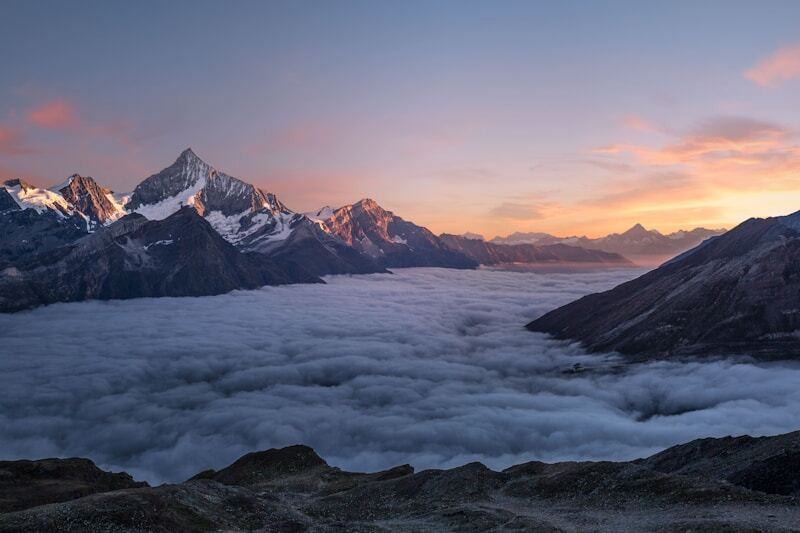

In [ ]:
# Prepare image
image_path = "../../files/images.png"
with open(image_path, "rb") as image_file:
    image_b64 = base64.b64encode(image_file.read()).decode()
image_uri = f"data:image/png;base64,{image_b64}"
print(image_uri)

In [ ]:
message = Message(
    role="user",
    contents=[
        Content.from_text("Please find the relevant furniture according to the image and give the corresponding price for each piece of furniture."),
        Content.from_uri(uri=image_uri, media_type="image/png"),
    ]
)

In [10]:
result = await agent.run(message)

ChatClientException: ('<class \'agent_framework_foundry._chat_client.FoundryChatClient\'> service failed to complete the prompt: Error code: 400 - {\'error\': {\'code\': \'invalid_payload\', \'message\': "\'...\' is not a valid absolute URI [Request ID: 6615f9580b74d3956e4025a7851f7b02]", \'param\': \'input[1].content[1].image_url\', \'type\': \'invalid_request_error\', \'details\': [{\'code\': \'ValidationError\', \'message\': "\'...\' is not a valid absolute URI", \'param\': \'input[1].content[1].image_url\', \'type\': \'error\', \'details\': []}], \'additionalInfo\': {\'request_id\': \'6615f9580b74d3956e4025a7851f7b02\'}}}', BadRequestError('Error code: 400 - {\'error\': {\'code\': \'invalid_payload\', \'message\': "\'...\' is not a valid absolute URI [Request ID: 6615f9580b74d3956e4025a7851f7b02]", \'param\': \'input[1].content[1].image_url\', \'type\': \'invalid_request_error\', \'details\': [{\'code\': \'ValidationError\', \'message\': "\'...\' is not a valid absolute URI", \'par

In [ ]:
print(result.text)